In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Opis danych

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

(303, 14)
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Kolumny przedstawiają 13 cech pacjenta, kolumna target przedstawia czy ktoś jest chory czy zdrowy. Mamy 4 wartości brakujące w kolumnie 'ca' oraz 2 w 'thal', przez to, że to mała część zbioru to usuwamy te wpisy.

Oznaczenia poszczególnych cech:
-age — wiek
-sex — płeć (0 = kobieta, 1 = mężczyzna)
- trestbps — ciśnienie krwi w spoczynku
- chol — poziom cholesterolu
- fbs — cukier we krwi na czczo
- thalach — maksymalne tętno
- itd.

## Przygotowanie danych

In [4]:
df = df.dropna()
print(df.shape)

(297, 14)


In [5]:
df['target'] = (df['target'] > 0).astype(int)
df['target'].value_counts()

target
0    160
1    137
Name: count, dtype: int64

##  Trening modelu i analiza wyników

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(237, 13) (60, 13)


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

[[28  4]
 [ 6 22]]


Macierz pomyłek:
- TN = 28, zdrowi poprawnie wykryci
- TP = 22, chorzy poprawnie wykryci
- FP = 4, zdrowi jako chorzy
- FN = 6, chorzy jako zdrowi

Precision = 0.85, 85% chorych z oznaczonych

Recall = 0.79, z wszystkich chorych 79% wykrytych

W naszym przypadku recall jest ważniejsze od precision, ponieważ najgorszy bład dla nas to False Negative, czyli chorzy zaklasyfikowani jako zdrowi, co jest największym zagrożeniem dla pacjenta.

## Krzywa ROC

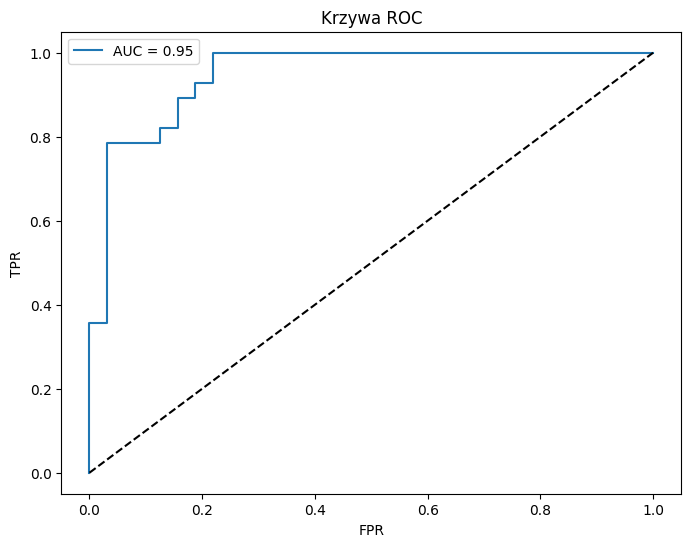

In [8]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Krzywa ROC')
plt.legend()
plt.show()

Przerywana linia - losowy klasyfikator AUC = 0.5 (zgadywanie).

Krzywa ROC - pokazuje kompromis pomiędzy TPR (wykryci chorzy), a FPR (zdrowi oznaczeni jako chorzy).

AUC - pole pod krzywą, 95% oznacza, że w tylu procentach przypadków poprawnie przypisuje wyższe prawdopodobienstwo choremu pacjentowi.

## Normalizacja i standaryzacja

In [9]:
results = {}

results['brak'] = {
    'acc': accuracy_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred)
}

# standaryzacja
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
m = LogisticRegression(max_iter=1000)
m.fit(X_train_std, y_train)
y_pred_std = m.predict(X_test_std)
results['standaryzacja'] = {
    'acc': accuracy_score(y_test, y_pred_std),
    'recall': recall_score(y_test, y_pred_std)
}

# normalizacja
scaler2 = MinMaxScaler()
X_train_norm = scaler2.fit_transform(X_train)
X_test_norm = scaler2.transform(X_test)
m2 = LogisticRegression(max_iter=1000)
m2.fit(X_train_norm, y_train)
y_pred_norm = m2.predict(X_test_norm)
results['normalizacja'] = {
    'acc': accuracy_score(y_test, y_pred_norm),
    'recall': recall_score(y_test, y_pred_norm)
}

pd.DataFrame(results).T

,acc,recall
brak,0.833333,0.785714
standaryzacja,0.833333,0.785714
normalizacja,0.833333,0.785714


Standaryzacja i normalizacja dają takie same wyniki co ich brak, jest to spowodowane brakiem outlierów oraz brakiem róznych skal między kolumnami, dane są relatywnie podobne.

### Badanie wpływu siły regularyzacji

In [10]:
results_c = {}

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = LogisticRegression(max_iter=1000, C=C)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    results_c[C] = {
        'acc': accuracy_score(y_test, y_p),
        'recall': recall_score(y_test, y_p)
    }

pd.DataFrame(results_c).T

,acc,recall
0.001,0.766667,0.535714
0.010,0.866667,0.785714
0.100,0.850000,0.785714
1.000,0.833333,0.785714
10.000,0.833333,0.785714
100.000,0.833333,0.785714


Przy małym c = 0.001 model jest zbyt prosty, acc i recall wyraźnie niższe w porównaniu do innych. Najlepszy wynik przy c = 0.01, większe c mają niewiele gorsze wyniki.

### Badanie wpływu l1_ratio

In [11]:
results_l1 = {}

for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    m = LogisticRegression(max_iter=1000, C=0.01,
                           solver='saga',
                           l1_ratio=ratio)

    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    results_l1[ratio] = {
        'acc': accuracy_score(y_test, y_p),
        'recall': recall_score(y_test, y_p)
    }

pd.DataFrame(results_l1).T

,acc,recall
0.00,0.866667,0.785714
0.25,0.850000,0.714286
0.50,0.533333,0.000000
0.75,0.533333,0.000000
1.00,0.533333,0.000000


Przy tym zbiorze l1_ratio słabo się sprawdza, dla wyższych współczyników pogarsza się accuracy, a recall spada do 0.

## Cross validation

In [12]:
model_cv = LogisticRegression(max_iter=1000, C=0.01)
print("Bez stratyfikacji:")
for k in [2, 5, 10]:
    kf = KFold(n_splits=k)
    scores = cross_val_score(model_cv, X_train_std, y_train, cv=kf, scoring='recall')
    print(f"{k}-fold, mean={scores.mean():.3f}, std={scores.std():.3f}")

print("\nZ stratyfikacją:")

for k in [2, 5, 10]:
    skf = StratifiedKFold(n_splits=k)
    scores = cross_val_score(model_cv, X_train_std, y_train, cv=skf, scoring='recall')
    print(f"{k}-fold, mean={scores.mean():.3f}, std={scores.std():.3f}")

Bez stratyfikacji:
2-fold, mean=0.708, std=0.162
5-fold, mean=0.730, std=0.151
10-fold, mean=0.729, std=0.156

Z stratyfikacją:
2-fold, mean=0.714, std=0.140
5-fold, mean=0.732, std=0.151
10-fold, mean=0.724, std=0.160


Zbiór jest zbalansowany z tego powodu stratyfikacja nie zmienia zbytnio wyników. Najbardziej zauważalna zmiana jest przy std, 2 fold z 0.162 na 0.140